In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
import numpy as np 
import seaborn as sns 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [2]:
data=pd.read_csv('play_tennis.csv')


In [3]:
data.head(5)

,day,outlook,temp,humidity,wind,play
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes


In [ ]:
df = data.drop(['day'], axis=1)

In [ ]:
# encoder 
from sklearn.preprocessing import  OrdinalEncoder
outlook_encoder = OrdinalEncoder()
df['outlook'] = outlook_encoder.fit_transform(df[['outlook']])
temp_encoder = OrdinalEncoder()
df['temp'] = temp_encoder.fit_transform(df[['temp']])
humidity_encoder = OrdinalEncoder()
df['humidity'] = humidity_encoder.fit_transform(df[['humidity']])
windy_encoder = OrdinalEncoder()
df['wind'] = windy_encoder.fit_transform(df[['wind']])
play_encoder = OrdinalEncoder()
df['play'] = play_encoder.fit_transform(df[['play']])


In [11]:
df.head(5)

,outlook,temp,humidity,wind,play
0,2.0,1.0,0.0,1.0,0.0
1,2.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,1.0,1.0
3,1.0,2.0,0.0,1.0,1.0
4,1.0,0.0,1.0,1.0,1.0


In [12]:
x = df.drop(['play'], axis=1)
y = df['play']

In [13]:
x

,outlook,temp,humidity,wind
0,2.0,1.0,0.0,1.0
1,2.0,1.0,0.0,0.0
2,0.0,1.0,0.0,1.0
3,1.0,2.0,0.0,1.0
4,1.0,0.0,1.0,1.0
5,1.0,0.0,1.0,0.0
6,0.0,0.0,1.0,0.0
7,2.0,2.0,0.0,1.0
8,2.0,0.0,1.0,1.0
9,1.0,2.0,1.0,1.0


In [14]:
y

0     0.0
1     0.0
2     1.0
3     1.0
4     1.0
5     0.0
6     1.0
7     0.0
8     1.0
9     1.0
10    1.0
11    1.0
12    1.0
13    0.0
Name: play, dtype: float64

In [15]:
x_train, x_test, y_train,y_test=train_test_split(x,y,test_size=0.2 , random_state=42)

In [16]:
x_train

,outlook,temp,humidity,wind
12,0.0,1.0,1.0,1.0
5,1.0,0.0,1.0,0.0
8,2.0,0.0,1.0,1.0
2,0.0,1.0,0.0,1.0
1,2.0,1.0,0.0,0.0
13,1.0,2.0,0.0,0.0
4,1.0,0.0,1.0,1.0
7,2.0,2.0,0.0,1.0
10,2.0,2.0,1.0,0.0
3,1.0,2.0,0.0,1.0


In [17]:
#classifier with ID3 and Gini 
clf = DecisionTreeClassifier(criterion='gini', random_state=42)
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)

clf1 = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf1.fit(x_train, y_train)
y_pred1 = clf1.predict(x_test)



In [19]:
# evaluating 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy with Gini:", accuracy_score(y_test, y_pred))
print("Classification Report with Gini:\n", classification_report(y_test, y_pred))
print("Confusion Matrix with Gini:\n", confusion_matrix(y_test, y_pred))



Accuracy with Gini: 1.0
Classification Report with Gini:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         1
         1.0       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

Confusion Matrix with Gini:
 [[1 0]
 [0 2]]


In [20]:
print("Accuracy with Entropy:", accuracy_score(y_test, y_pred1))
print("Classification Report with Entropy:\n", classification_report(y_test, y_pred1))
print("Confusion Matrix with Entropy:\n", confusion_matrix(y_test, y_pred1))

Accuracy with Entropy: 1.0
Classification Report with Entropy:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         1
         1.0       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

Confusion Matrix with Entropy:
 [[1 0]
 [0 2]]


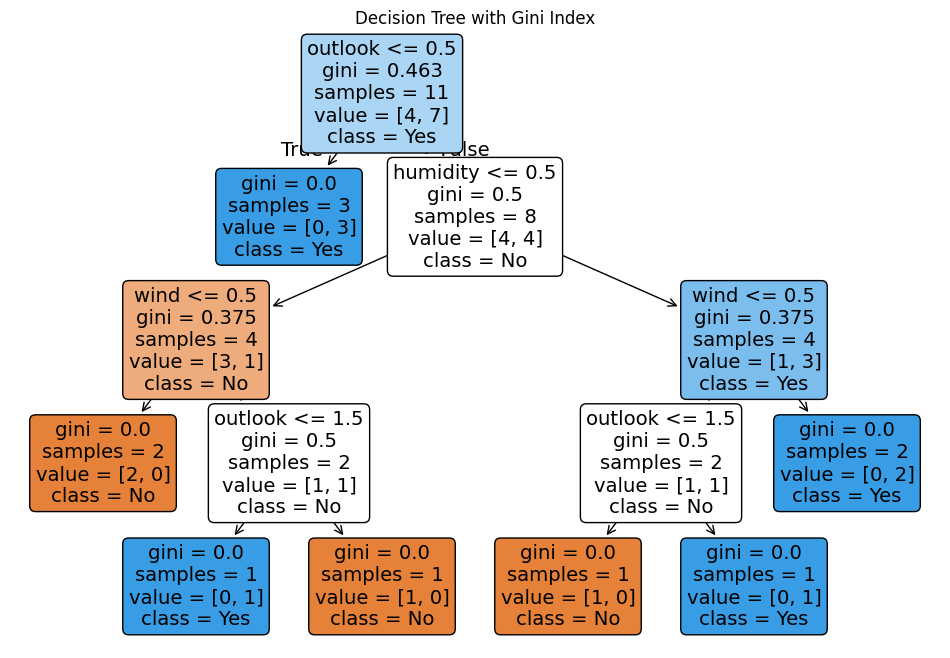

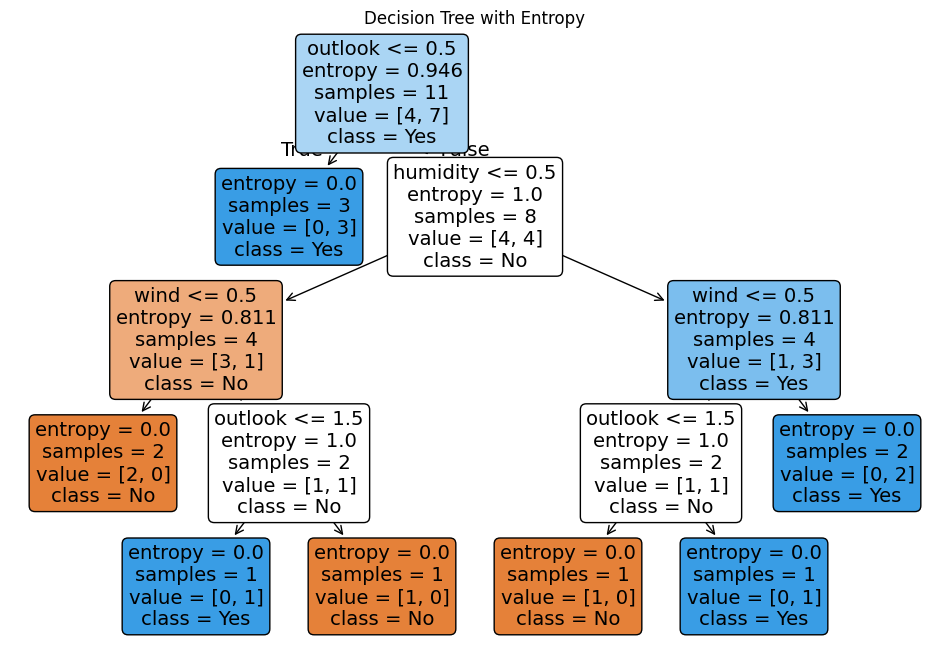

In [21]:
from sklearn import tree 
plt.figure(figsize=(12,8))
tree.plot_tree(clf, filled=True, feature_names=x.columns, class_names=play_encoder.categories_[0], rounded=True)
plt.title("Decision Tree with Gini Index")
plt.show()
plt.figure(figsize=(12,8))
tree.plot_tree(clf1, filled=True, feature_names=x.columns, class_names=play_encoder.categories_[0], rounded=True)
plt.title("Decision Tree with Entropy")
plt.show()

